# 실습 5-2 : SHAP Value

#### **<실습 내용>**

1. SHAP - 회귀 모델 (Regression)
- TreeExplainer를 사용한 SHAP 분석
- Summary Plot / Force Plot / Dependence Plot

3. SHAP - 분류 모델 (Classification)
- TreeExplainer를 사용한 SHAP 분석
- Summary Plot / Force Plot / Dependence Plot

## 분석 준비

### 주요 라이브러리 호출

In [1]:
!pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   --- ------------------------------------ 3.7/41.9 MB 18.1 MB/s eta 0:00:03
   ------- -------------------------------- 7.9/41.9 MB 18.7 MB/s eta 0:00:02
   ----------- ---------------------------- 11.5/41.9 MB 18.0 MB/s eta 0:00:02
   --------------- ------------------------ 16.5/41.9 MB 19.3 MB/s eta 0:00:02
   -------------------- ------------------- 21.0/41.9 MB 19.8 MB/s eta 0:00:02
   ------------------------ --------------- 25.7/41.9 MB 20.1 MB/s eta 0:00:01
   ----------------------------- ---------- 30.4/41.9 MB 20.5 MB/s eta 0:00:01
   --------------------------------- ------ 34.6/41.9 MB 20.5 MB/s eta 0:00:01
   ------------------------------------ --- 38.3/41.9 MB 20.1 MB/s eta 0:00:01
   ---------------------------------------  41.7/41.9 MB 20.4 MB/s eta 0:00:01
   ---------------------------------------- 41.9/41.9 MB 19.4 MB/s  0:00:02
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:

  You can safely remove it manually.
  You can safely remove it manually.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, f1_score
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

import shap

c:\Users\Admin\miniconda3\envs\day4\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 1) SHAP - 회귀 모델

In [3]:
# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

### 1-1) 데이터 및 모델 준비

In [4]:
Regression = pd.read_csv("dataset/day5-2_reg_data.csv")
Regression

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X50,X51,X52,X53,X54,X55,X56,X57,X58,y
0,0.40420,0.39615,0.34470,0.39535,0.44180,0.38830,0.36245,0.34480,0.32475,0.38020,...,0.39200,0.34985,0.37980,0.42355,0.38990,0.40890,0.41720,0.37765,0.36190,48.272178
1,0.47115,0.35280,0.29120,0.30190,0.54875,0.40430,0.42125,0.32620,0.35280,0.43115,...,0.32080,0.35185,0.35570,0.38400,0.44375,0.25945,0.55030,0.43205,0.31395,49.767621
2,0.31185,0.35220,0.41940,0.38370,0.30015,0.32555,0.39790,0.44730,0.55625,0.60885,...,0.36105,0.36230,0.30455,0.26945,0.49770,0.37425,0.27800,0.41980,0.37620,45.512356
3,0.43900,0.38300,0.38830,0.33920,0.40740,0.40650,0.45455,0.40565,0.41915,0.33565,...,0.33715,0.46605,0.45040,0.37150,0.37625,0.28595,0.45195,0.40570,0.39885,55.646432
4,0.38005,0.42835,0.53105,0.39145,0.31755,0.40365,0.33230,0.48530,0.44295,0.37615,...,0.43555,0.30330,0.26910,0.35155,0.42230,0.43660,0.35875,0.43605,0.46260,47.703096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,0.40675,0.37110,0.29385,0.37125,0.43345,0.32380,0.40365,0.32200,0.35655,0.50940,...,0.31965,0.32385,0.37480,0.37240,0.46065,0.33660,0.40075,0.37875,0.30040,44.683854
237,0.37940,0.36660,0.39205,0.42100,0.37860,0.42690,0.39580,0.39240,0.39080,0.35705,...,0.43260,0.40485,0.36410,0.45070,0.37270,0.45270,0.36685,0.39055,0.40395,47.907255
238,0.35150,0.35285,0.24365,0.40190,0.50055,0.37125,0.36820,0.28830,0.34130,0.48590,...,0.38300,0.38705,0.41305,0.40750,0.39510,0.40895,0.40825,0.35865,0.30240,45.900853
239,0.30580,0.46180,0.50870,0.43220,0.38695,0.43260,0.24155,0.45805,0.38565,0.29875,...,0.51305,0.36490,0.35580,0.36160,0.31170,0.53040,0.36960,0.38475,0.49090,51.418961


In [5]:
X_reg = Regression.drop(["y"], axis=1) # 입력변수
Y_reg = Regression["y"] # 출력변수

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(X_reg, Y_reg, test_size=0.2, random_state=42) # 학습/테스트 데이터 분할

In [6]:
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0) # RandomForest로 모델 학습
rf_reg.fit(X_train_reg, Y_train_reg)
Y_pred_reg = rf_reg.predict(X_test_reg)
get_regscore(Y_test_reg, Y_pred_reg)

MSE       : 6.598
RMSE      : 2.569
MAE       : 1.991
R-squared : 0.558


### 2-2) SHAP 분석

In [7]:
# rf_reg 모델을 해석하기 위한 SHAP 설명자 생성
explainer_reg = shap.TreeExplainer(rf_reg)

# 학습 데이터(X_train_reg)에 대한 SHAP value 계산
# 각 feature가 예측값에 기여하는 정도를 나타냄
shap_values_reg = explainer_reg.shap_values(X_train_reg)

#### Summary Plot (Bar)
- 막대가 길수록 예측에 영향을 많이 주는 변수라는 뜻임

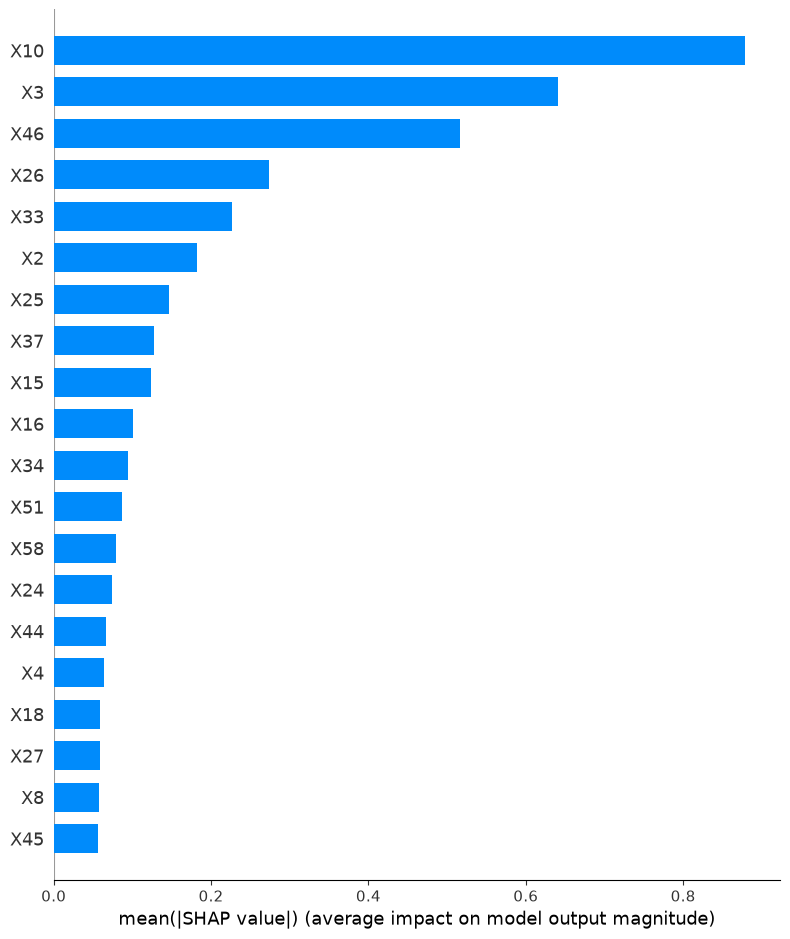

In [8]:
shap.summary_plot(shap_values_reg, X_train_reg, plot_type='bar')

#### Summary Plot (Scatter)
- 오른쪽에 점이 몰려있으면 예측값을 올리는 변수, 왼쪽에 몰려있으면 예측값을 낮추는 변수임

> - 빨간색: 높은 변수 값
> - 파란색: 낮은 변수 값

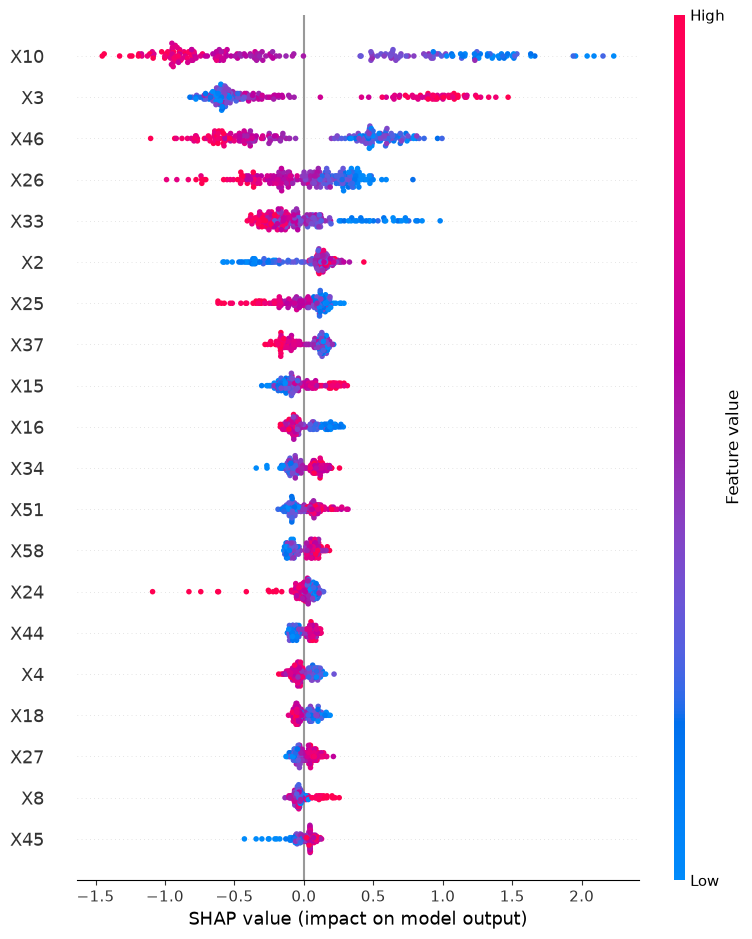

In [9]:
shap.summary_plot(shap_values_reg, X_train_reg)

#### Force Plot (개별 데이터)
- 데이터 하나를 뽑아서 어떤 변수가 예측값을 올렸고 내렸는지 화살표로 보여주는 그래프임

In [10]:
base_value_reg = explainer_reg.expected_value
print(base_value_reg)

[49.74460342]


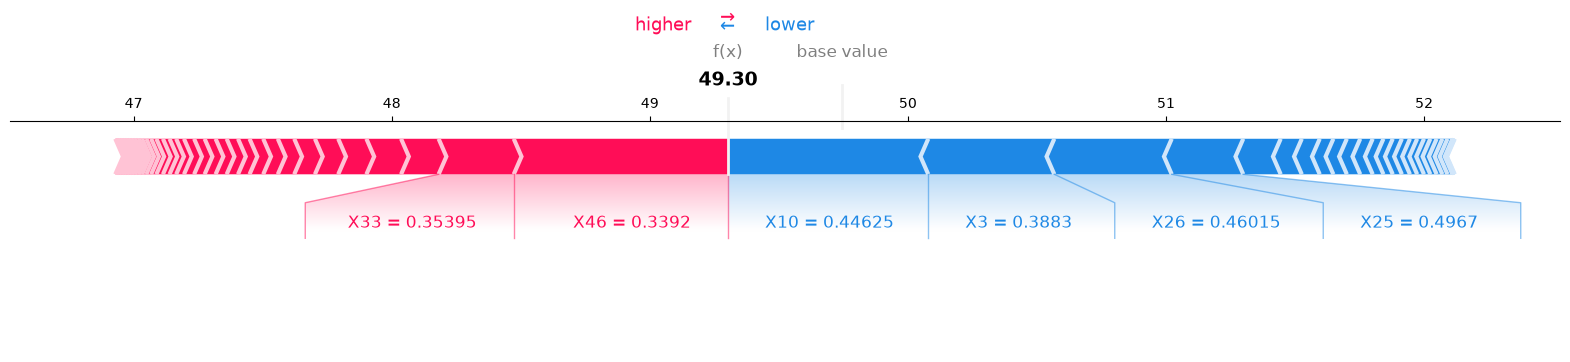

In [11]:
# 첫 번째 데이터(index 0)의 예측 결과를 force plot으로 시각화
# expected_value: 전체 데이터의 평균 예측값 (기준선)
# shap_values_reg[0]: 이 데이터의 각 feature별 SHAP value 
# X_train_reg.iloc[0]: 실제 feature 값들 (그래프에 표시용)

shap.force_plot(
    explainer_reg.expected_value,
    shap_values_reg[0],
    X_train_reg.iloc[0],
    matplotlib=True
)

#### Dependence Plot
- 변수 값이 변할 때 SHAP 값(영향력)이 같이 어떻게 움직이는지 보여주는 그래프임

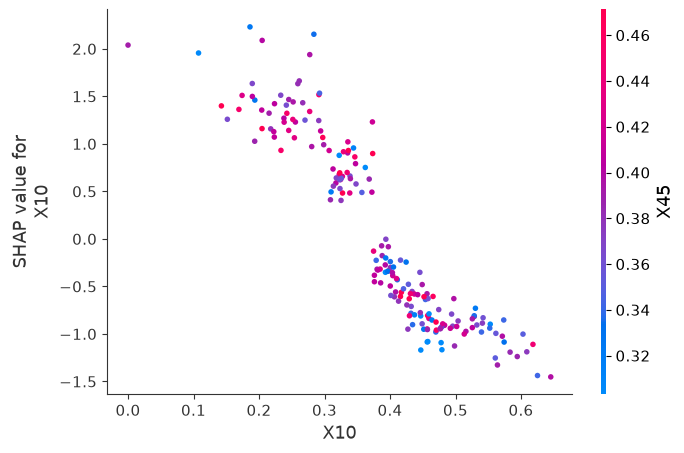

In [12]:
# "X10" feature 값에 따라 SHAP value가 어떻게 변하는지 시각화
# x축: X10의 실제 값, y축: X10의 SHAP value (예측에 미친 영향)
# 자동으로 X10과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X10",
    shap_values_reg,
    X_train_reg
)

좋은 질문입니다. **X10, X45가 “온도”, “압력” 같은 실제 의미를 갖는 변수는 아닙니다.** 이 실습 데이터는 `day5-2_reg_data.csv`에 `X1`~`X58`, `y`처럼 **이름만 붙은 인공(익명) 데이터**입니다.

그래서 이 plot에서는 **“X10이 뭔지”보다 “X10 값이 바뀔 때 예측이 어떻게 바뀌는지”**를 읽는 것이 핵심입니다.

---

## 1. 이 그래프가 보여주는 것

**SHAP Dependence Plot** = “한 변수의 **값**이 변할 때, 그 변수의 **SHAP 값(예측 기여도)**이 어떻게 변하는가”

| 요소 | 의미 |
|------|------|
| **가로축 (X10)** | 각 샘플에서 `X10`의 **실제 값** |
| **세로축 (SHAP value for X10)** | 그 샘플에서 `X10`이 예측값 `y`에 **얼마나 기여했는지** |
| **점 색깔 (X45)** | SHAP이 **자동으로** 골라 준, `X10`과 **상호작용이 큰 변수** |

SHAP 값 해석:
- **양수(+)**: 평균 예측보다 **올리는** 방향
- **음수(-)**: 평균 예측보다 **내리는** 방향
- **0 근처**: 영향 거의 없음

---

## 2. X10은 무엇인가?

**10번째 입력 변수**일 뿐, 도메인 의미는 없습니다.

이 plot에서는 이렇게 읽으면 됩니다:

> **“X10이 작을 때(왼쪽) → 예측을 올리는 경향(+)**  
> **X10이 클 때(오른쪽) → 예측을 내리는 경향(-)”**

즉 모델이 학습한 관계는 대략 **X10 ↑ → y ↓** (음의 관계)입니다.

그래프에서도:
- `X10` ≈ 0.0~0.35 → SHAP **+0.5 ~ +2.0**
- `X10` ≈ 0.4~0.65 → SHAP **-0.2 ~ -1.5**

`X10 ≈ 0.35` 근처에 점이 비어 있는 것은, **학습 데이터에 그 구간 값이 거의 없어서** 그렇게 보이는 것입니다.

---

## 3. X45는 무엇인가?

**45번째 입력 변수**이고, 마찬가지로 실제 의미는 없습니다.

여기서 중요한 점: **X45는 우리가 직접 고른 게 아닙니다.**

```python
shap.dependence_plot("X10", shap_values_reg, X_train_reg)
```

이 함수가 `X10`과 **가장 상호작용이 큰 변수**를 찾아 **색으로 칠해 줍니다.**  
이번 그래프에서는 그게 `X45`였습니다.

색의 의미:
- **파란색**: `X45` 값이 **낮은** 샘플
- **분홍색**: `X45` 값이 **높은** 샘플

같은 `X10` 값이라도 `X45`에 따라 SHAP이 조금 달라지면 → **“X10의 효과가 X45에 따라 달라진다”** = **상호작용(interaction)** 이 있습니다.

예를 들어 `X10`이 0.4~0.5 구간에서:
- `X45`가 높으면(분홍) SHAP이 상대적으로 덜 음수
- `X45`가 낮으면(파랑) SHAP이 더 음수

→ **X10이 클 때, X45가 높으면 예측을 덜 내리는 쪽**으로 작용할 수 있다는 뜻입니다.

---

## 4. 한 문장으로 정리

| 변수 | 이 plot에서의 역할 |
|------|-------------------|
| **X10** | 분석 대상. 값이 커질수록 예측을 **낮추는** 변수 |
| **X45** | X10 효과를 **조건에 따라 바꾸는** 변수 (색으로 표시) |

**“X10이 뭔지”보다 “X10이 예측에 어떤 방향·크기로 기여하는지”, 그리고 “그 효과가 X45에 따라 달라지는지”**를 보는 그래프입니다.

---

## 5. Day 5-1 데이터와 비교하면

Day 5-1에서는 `TAE.MEAN6`, `CROT.MEAN4`처럼 **이름에 의미**가 있었습니다.  
Day 5-2는 SHAP **해석 방법 연습**용이라 변수명이 `X1`, `X2`, … 로만 되어 있습니다.

실무에서는:
- `X10` → `고객 연령`, `공정 온도` 같은 **실제 변수명**
- `X45` → `멤버십 등급`, `챔버 번호` 같은 **상호작용 변수**

으로 바꿔 같은 방식으로 읽으면 됩니다.

---

## 6. 읽는 순서 (실습용 체크리스트)

1. **가로축 방향**으로 점이 올라가는지/내려가는지 → X10과 y의 관계 방향
2. **세로축 절대값** → 영향력 크기
3. **색이 섞여 있는지** → X45와의 상호작용 여부
4. **빈 구간** → 데이터가 sparse한 구간 (해석 주의)

원하시면 `summary_plot`에서 **X10이 몇 번째로 중요한 변수인지**, 또는 **X45 대신 다른 색 변수를 지정하는 코드**도 같이 설명해 드리겠습니다.

---

## 3) SHAP - 분류 모델

In [13]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

### 3-1) 데이터 및 모델 준비

In [14]:
Classification = pd.read_csv("dataset/day5-2_cls_data.csv")
Classification

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X466,X467,X468,X469,X470,X471,X472,X473,X474,Y
0,0.457896,0.530189,0.276976,0.359864,0.193059,0.322190,0.706897,0.553781,0.653894,0.375204,...,0.246376,0.711806,0.008532,0.013672,0.008467,0.402240,0.238811,0.274876,0.210238,-1
1,0.607100,0.341478,0.518992,0.395300,0.042071,0.469654,0.750000,0.542031,0.447466,0.189233,...,0.523785,0.760417,0.030930,0.033203,0.029759,0.210356,0.309339,0.328358,0.439175,-1
2,0.360781,0.369653,0.341039,0.021697,0.181737,0.528684,0.491379,0.516722,0.300371,0.376835,...,0.185769,0.659722,0.005333,0.003906,0.005311,0.381877,0.208171,0.208955,0.155761,-1
3,0.460910,0.413500,0.535685,0.302794,0.242326,0.408966,0.646552,0.561615,0.415328,0.313214,...,0.246376,0.000000,1.000000,1.000000,1.000000,0.381877,0.208171,0.208955,0.155761,-1
4,0.263068,0.279821,0.535685,0.302794,0.242326,0.408966,0.646552,0.638747,0.660074,0.520392,...,0.110711,0.517361,0.023677,0.022461,0.023447,0.608414,0.212062,0.268657,0.092827,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,0.360022,0.396033,0.382803,0.070771,0.143308,0.920884,0.586207,0.636336,0.337454,0.432300,...,0.000000,0.597222,0.016212,0.013672,0.015997,0.045307,0.147860,0.171642,0.000000,1
250,0.508628,0.437628,0.192378,0.061866,0.168425,0.481919,0.715517,0.270563,0.407911,0.336052,...,0.132582,0.975694,0.017065,0.015625,0.016114,0.543689,0.227626,0.320896,0.111165,1
251,0.275930,0.364365,0.302236,0.376615,0.485135,0.627270,0.594828,0.435673,0.420272,0.367047,...,0.246376,0.586806,0.008532,0.015625,0.008613,0.343042,0.151751,0.164179,0.143012,1
252,0.785179,0.271804,0.400189,0.457851,0.229526,0.244320,0.396552,0.875565,0.110012,0.337684,...,0.221768,0.767361,0.024317,0.019531,0.023461,0.509709,0.398833,0.440299,0.185945,1


In [15]:
X_cls = Classification.drop(["Y"], axis=1) # 입력변수
Y_cls = Classification["Y"] # 출력변수

X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.2, random_state=123, stratify=Y_cls)

rf_cls = RandomForestClassifier(n_estimators=100, random_state=0)
rf_cls.fit(X_train_cls, Y_train_cls)
Y_pred_cls = rf_cls.predict(X_test_cls)
get_classscore(Y_test_cls, Y_pred_cls)

Accuracy  : 0.863
Precision : 0.938
Recall    : 0.714
F1-score  : 0.811

혼동행렬
[[29  1]
 [ 6 15]]


### 3-2) SHAP 분석

In [16]:
explainer_cls = shap.TreeExplainer(rf_cls)
shap_values_cls = explainer_cls.shap_values(X_train_cls)

#### Summary Plot (Bar)

> 분류 모델의 경우 `shap_values_cls`는 (샘플 수, 변수 수, 클래스 수) 형태의 3차원 배열임
> - `shap_values_cls[:, :, 0]`: 클래스 -1에 대한 SHAP
> - `shap_values_cls[:, :, 1]`: 클래스 1에 대한 SHAP

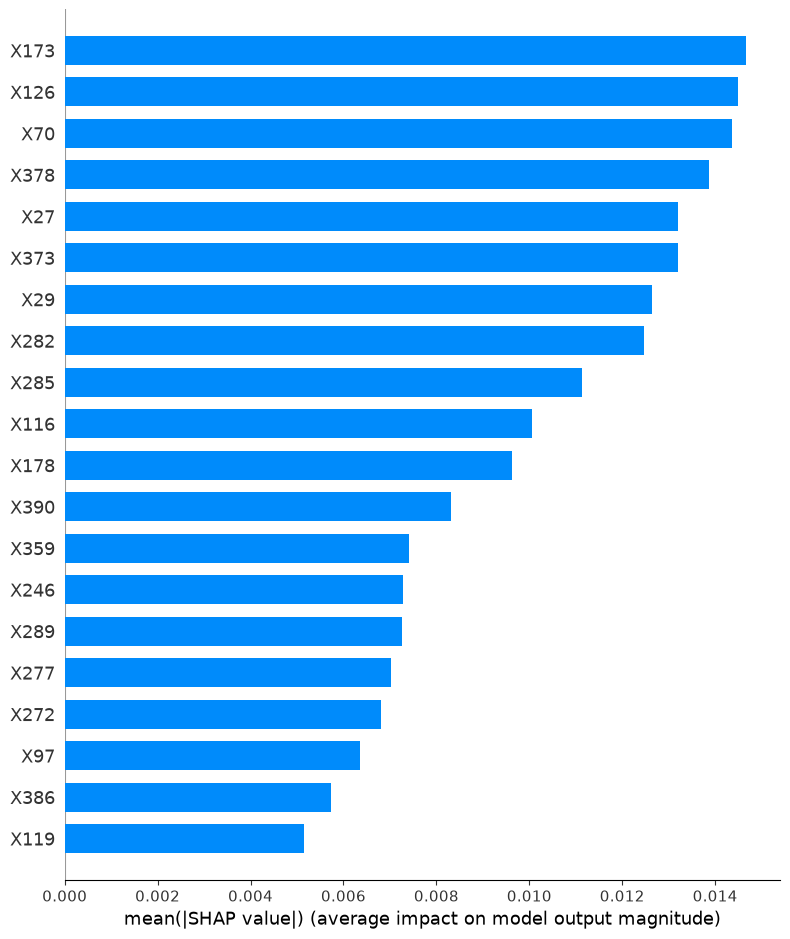

In [17]:
shap.summary_plot(shap_values_cls[:, :, 0], X_train_cls, plot_type='bar')  # 클래스 -1 기준

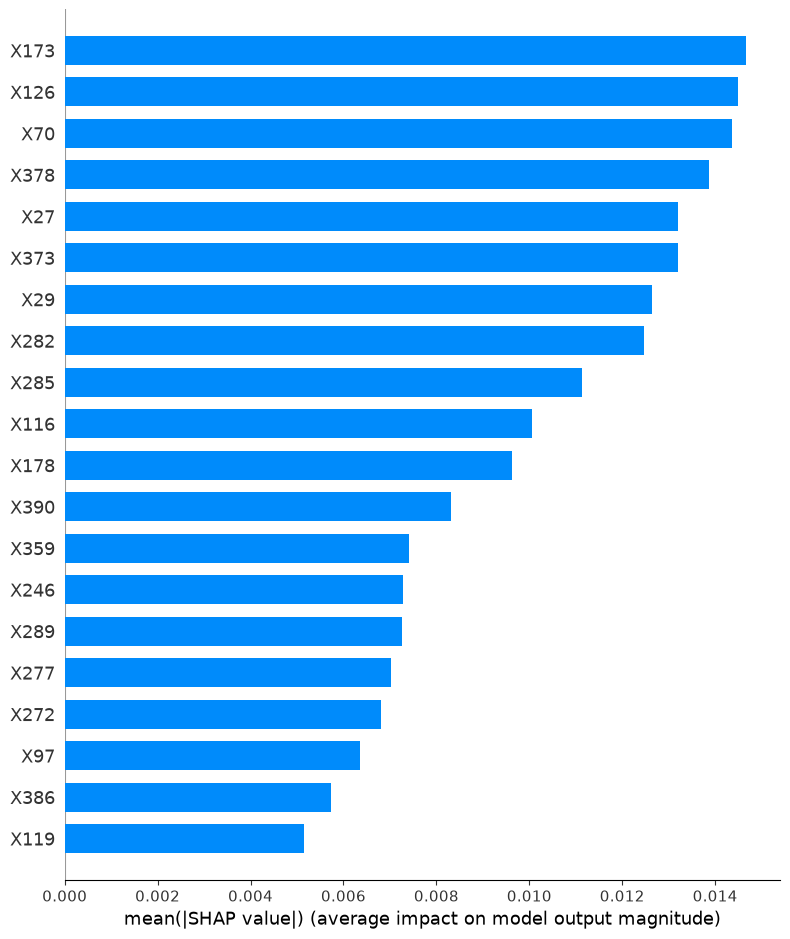

In [18]:
shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls, plot_type='bar')  # 클래스 1 기준

#### Summary Plot (Scatter) - 클래스별

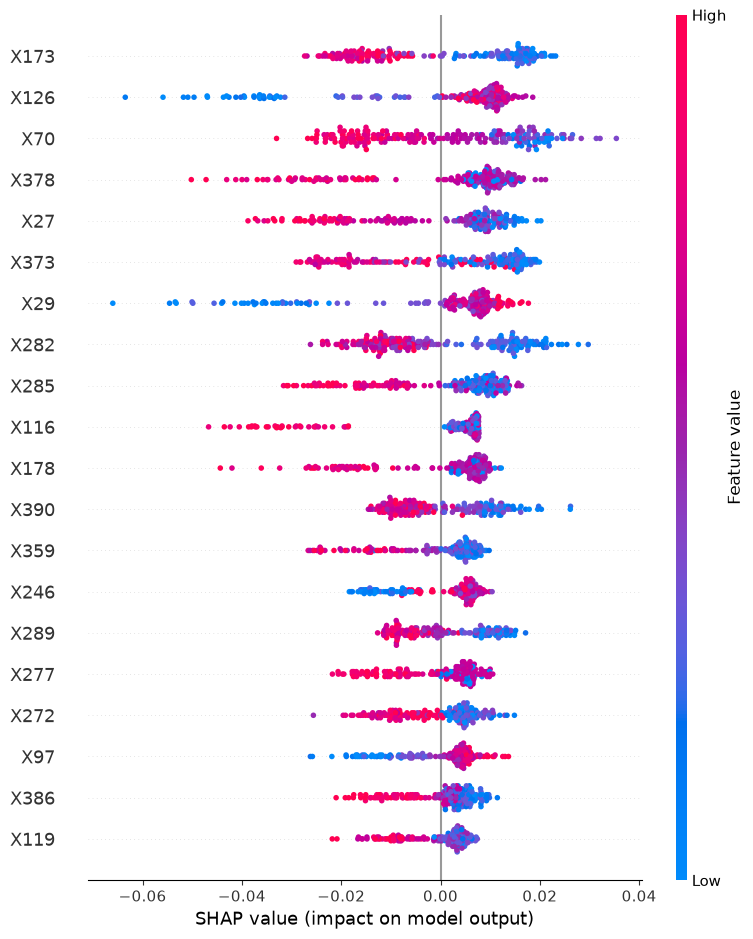

In [19]:
shap.summary_plot(shap_values_cls[:, :, 0], X_train_cls) # 클래스 = -1

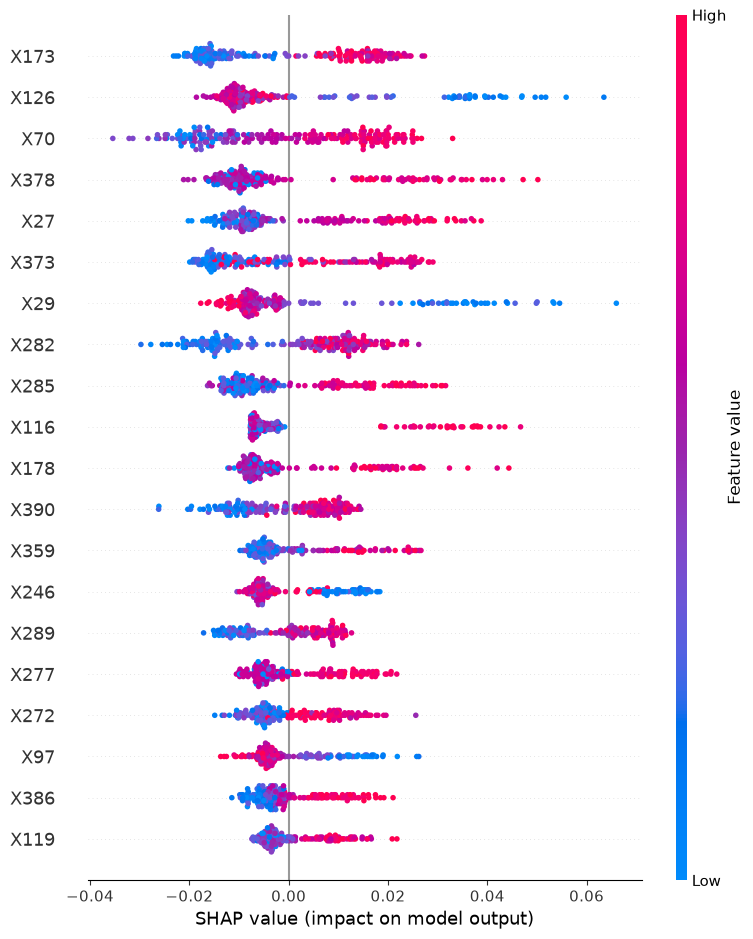

In [20]:
# 변수 중요도 순서는 같은데 부호가 반대 방향임

shap.summary_plot(shap_values_cls[:, :, 1], X_train_cls) # 클래스 = 1

#### Force Plot (개별 데이터)

In [22]:
# 15번 데이터의 실제(정답) 클래스 확인
Y_train_cls.iloc[15]

np.int64(-1)

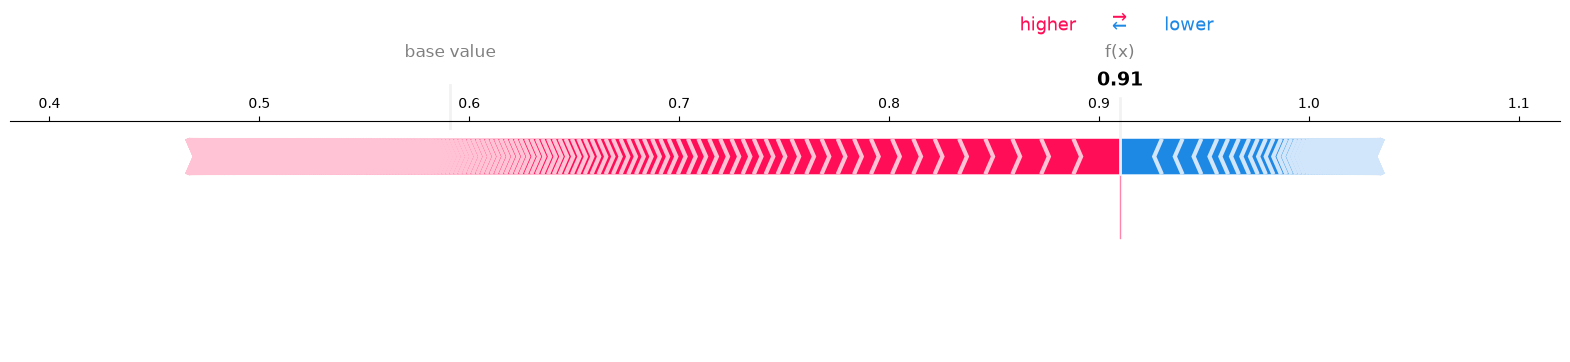

In [ ]:
# 15번 데이터를 클래스 -1로 예측하는 데 각 feature가 어떻게 기여했는지 시각화

# expected_value[0]: 클래스 -1에 대한 기준값(base value)
# shap_values_cls[15, :, 0]: 15번 데이터의, 클래스 -1에 대한 각 feature별 SHAP value
# X_train_cls.iloc[15]: 15번 데이터의 실제 feature 값들 

shap.force_plot(
    explainer_cls.expected_value[0],
    shap_values_cls[15, :, 0],
    X_train_cls.iloc[15],
    matplotlib=True
)

# 0.91의 확률로 -1로 예측한 데이터

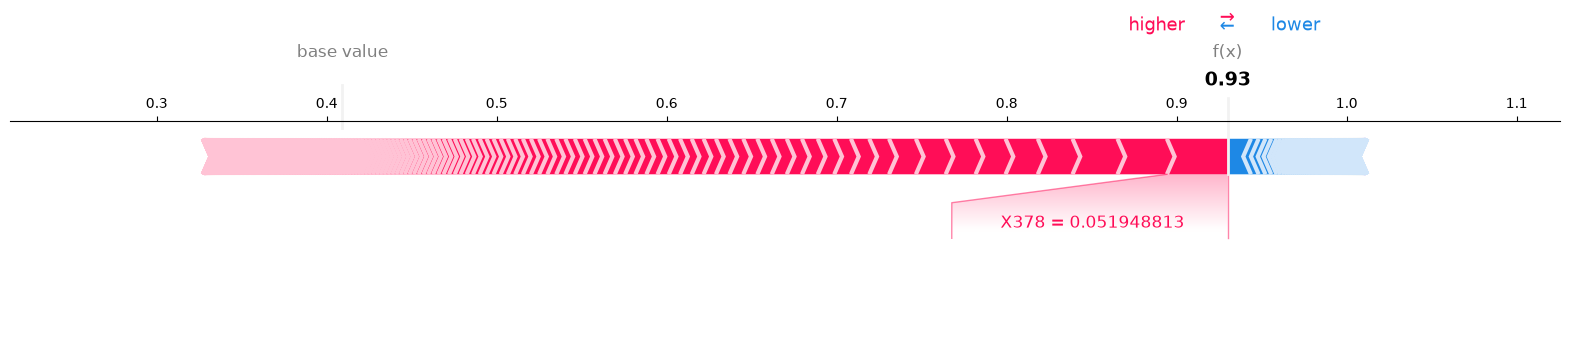

In [24]:
# 40번 데이터를 클래스 1로 예측하는 데 각 feature가 어떻게 기여했는지 시각화

# expected_value[1]: 클래스 1에 대한 기준값(base value)
# shap_values_cls[40, :, 1]: 40번 데이터의, 클래스 1에 대한 각 feature별 SHAP value
# X_train_cls.iloc[40]: 40번 데이터의 실제 feature 값들

shap.force_plot(
    explainer_cls.expected_value[1],
    shap_values_cls[40, :, 1],
    X_train_cls.iloc[40],
    matplotlib=True
)

#### Dependence Plot

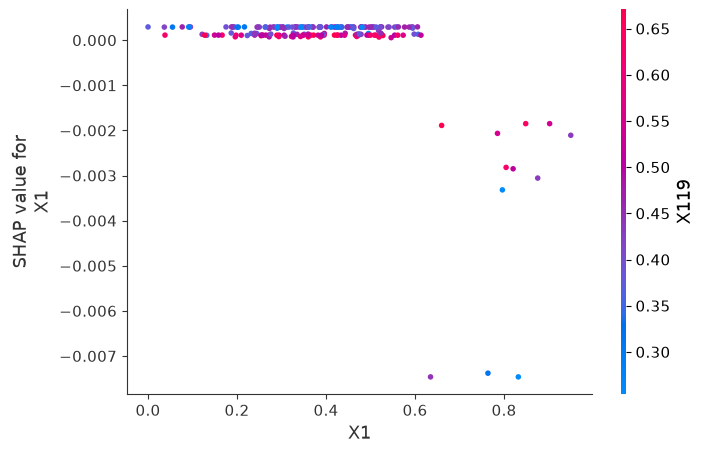

In [25]:
# "X1" feature 값에 따라, 클래스 -1에 대한 SHAP value가 어떻게 변하는지 시각화
# x축: X1의 실제 값, y축: X1의 클래스 -1 기준 SHAP value (예측에 미친 영향)
# 자동으로 X1과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X1",
    shap_values_cls[:, :, 0],
    X_train_cls
)

In [ ]:
# "X1" feature 값에 따라, 클래스 1에 대한 SHAP value가 어떻게 변하는지 시각화
# x축: X1의 실제 값, y축: X1의 클래스 1 기준 SHAP value (예측에 미친 영향)
# 자동으로 X1과 가장 상호작용이 큰 feature를 색상으로 표시

shap.dependence_plot(
    "X1",
    shap_values_cls[:, :, 1],
    X_train_cls
)

---

## 4) Vibe Coding 실습

**[과제 1]** 

지수는 Random Forest의 Feature Importance와 SHAP Value가 모두 변수의 중요도를 설명하는 방법이라는 것을 배웠습니다.

AI와 함께 Random Forest (회귀/분류)의 feature_importances_와 SHAP Summary Plot 결과를 비교해 보세요.

두 방법에서 중요하게 평가된 변수가 얼마나 비슷한지 확인하고 순위가 다른 변수는 왜 차이가 발생했는지 AI와 토의하여 해석해 보세요.

[프롬프트]
Random Forest (회귀/분류)의 feature_importances_와 SHAP Summary Plot 결과가 변수의 중요도를 각각 어떻게 설명하고 있는지 비교해보고 싶어. 

`feature_importances_`와 SHAP Summary Plot은 둘 다 “어떤 변수가 중요한가?”를 보여주지만, **중요도를 정의하는 방식이 다릅니다.** 실습 데이터로 실제 비교한 결과를 바탕으로 정리했습니다.

---

## 1. 한 줄로 비교

| | **RF `feature_importances_`** | **SHAP Summary Plot** |
|---|---|---|
| **질문** | “이 변수로 나눴을 때 불순도가 얼마나 줄었나?” | “이 변수가 예측값을 평균에서 얼마나 밀어 올리거나 내렸나?” |
| **단위** | 모델 내부 분할 기여도 (합=1) | 예측값 변화량 (y 단위) |
| **방향** | 없음 (크기만) | 있음 (+/-) |
| **범위** | 모델 전체 1개 순위 | 샘플별 기여 → 평균/집계 |

---

## 2. RF `feature_importances_`가 설명하는 것

Random Forest는 트리를 쪼갤 때마다 **불순도 감소량**(회귀: MSE 감소, 분류: Gini 감소)을 기록합니다.

```
feature_importances_ = 모든 트리에서
                         "이 변수로 split 했을 때 불순도가 줄어든 양"
                         을 평균한 값 (정규화해서 합=1)
```

**특징:**
- **전역(global)** 중요도: 개별 샘플이 아니라 데이터 전체 기준
- **방향 없음**: y를 올리는지 내리는지는 모름
- **모델에 종속**: RF가 실제로 쓴 split 기준만 반영
- **상관 변수 주의**: 비슷한 변수가 있으면 중요도가 나뉘거나 한쪽에 쏠릴 수 있음

**회귀 Top 5 (실습 데이터):**

| 순위 | 변수 | RF importance |
|------|------|---------------|
| 1 | X10 | 0.193 |
| 2 | X3 | 0.141 |
| 3 | X46 | 0.090 |
| 4 | X26 | 0.051 |
| 5 | X33 | 0.035 |

---

## 3. SHAP Summary Plot이 설명하는 것

SHAP은 각 샘플마다 **“이 변수가 예측을 평균 대비 얼마나 바꿨는가”**를 계산합니다.

### Bar plot (`plot_type='bar'`)
```
변수 중요도 = mean(|SHAP value|)
```
→ “평균적으로 예측에 미친 영향의 크기” (RF importance와 가장 비슷하게 비교 가능)

**회귀 Top 5 (bar plot과 동일한 수치):**

| 순위 | 변수 | mean(\|SHAP\|) |
|------|------|----------------|
| 1 | X10 | 0.879 |
| 2 | X3 | 0.641 |
| 3 | X46 | 0.516 |
| 4 | X26 | 0.274 |
| 5 | X33 | 0.227 |

순위는 RF와 거의 같지만, **수치 스케일은 다릅니다** (RF는 0~1 비율, SHAP은 예측값 단위).

### Dot plot (기본 summary plot)
- 가로축: SHAP 값 (양수 = 예측 ↑, 음수 = 예측 ↓)
- 색: 변수 값 (빨강=높음, 파랑=낮음)

→ **“중요한 변수가 예측을 어떤 방향으로, 어떤 값에서 바꾸는지”**까지 보여줍니다. RF에는 없는 정보입니다.

---

## 4. 실습 데이터 비교 결과

### 회귀 (RandomForestRegressor)

| 비교 항목 | 결과 |
|-----------|------|
| Top 10 겹침 | **9/10** (X10, X3, X46, X26, X33, X2, X25, X37, X15) |
| RF에만 Top 10 | X58 |
| SHAP에만 Top 10 | X16 |
| 순위 상관 (Spearman) | **0.95** — 매우 유사 |

### 분류 (RandomForestClassifier)

| 비교 항목 | 결과 |
|-----------|------|
| RF `feature_importances_` | 클래스 구분 없이 **하나의 순위** |
| SHAP bar (클래스 -1 / +1) | 클래스별로 별도 순위 가능 |
| Top 10 겹침 (양쪽 클래스) | **9/10** |
| RF에만 Top 10 | X277 |
| SHAP에만 Top 10 | X116 |
| 순위 상관 | **0.96** |

분류에서 RF Top 5: `X373, X126, X70, X29, X378`  
SHAP Top 5 (클래스 -1): `X173, X126, X70, X378, X27` — 변수 구성은 비슷하고 순서만 조금 다름.

---

## 5. 왜 순위는 비슷한데 완전히 같지는 않을까?

### ① 측정 대상이 다름
- **RF**: split 시 **불순도 감소**
- **SHAP**: **예측값 변화** (게임 이론 기반 공정 분배)

같은 모델이라도 “분할에 자주 쓰인 변수”와 “예측을 실제로 많이 바꾼 변수”가 100% 일치하지는 않습니다.

### ② 상관 변수 처리 방식
비슷한 `X1`~`X58` 변수가 많을 때:
- RF: split 기회를 **나눠 가짐**
- SHAP: 상호작용을 고려해 **기여를 분배**

### ③ 분류에서 RF vs SHAP 구조 차이

```
RF feature_importances_  →  전체 모델 1개 순위
SHAP (분류)             →  클래스 -1용 / 클래스 +1용 각각 순위
```

RF는 “전반적으로 split에 많이 쓰인 변수”이고,  
SHAP은 “**클래스 -1(또는 +1)로 예측하는 데** 기여한 변수”입니다.

---

## 6. 어떤 때 무엇을 보면 좋을까?

| 목적 | 추천 |
|------|------|
| 빠르게 전역 중요도 확인 | RF `feature_importances_` |
| 중요도 + **방향**(올림/내림) | SHAP dot summary plot |
| RF bar plot과 숫자 비교 | SHAP bar plot (`plot_type='bar'`) |
| 분류에서 클래스별 영향 | SHAP 클래스별 summary plot |
| 개별 샘플 설명 | SHAP force plot / waterfall |

---

## 정리

> **RF `feature_importances_`**: “이 모델이 트리를 나눌 때 **어떤 변수를 가장 유용하게 썼는가**”  
> **SHAP Summary Plot**: “이 변수가 **각 샘플의 예측을 평균에서 얼마나, 어느 방향으로** 움직였는가”

실습 데이터에서는 **순위가 95% 이상 일치**해서, “핵심 변수”는 두 방법이 같은 결론에 가깝습니다.  
차이는 **X58 vs X16**(회귀), **X277 vs X116**(분류) 같은 경계 변수에서 나타납니다.

SHAP의 추가 가치는 **방향(+/−)** 과 **샘플별·클래스별 해석**입니다. RF는 “누가 중요한가”만, SHAP은 “어떻게 중요한가”까지 알려줍니다.

C:\Users\Admin\AppData\Local\Temp\ipykernel_22396\1866897742.py:25: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_22396\1866897742.py:25: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_22396\1866897742.py:25: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_22396\1866897742.py:25: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_22396\1866897742.py:25: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_22396\1866897742.py:25: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing 

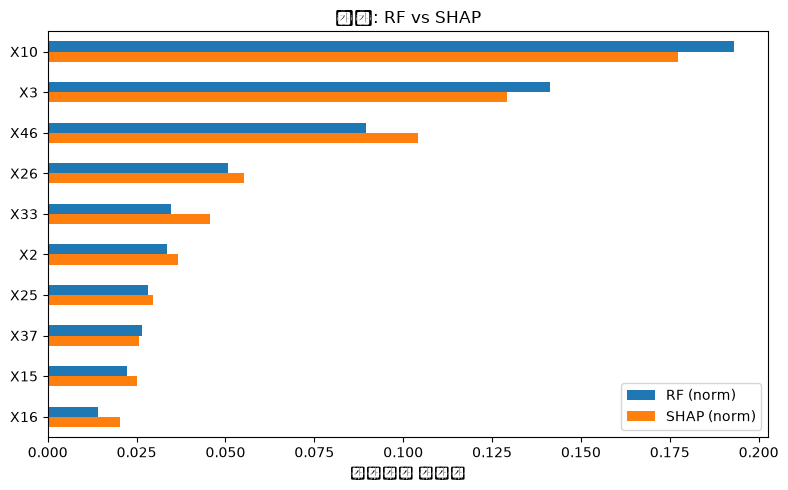

     RF (norm)  SHAP (norm)
X10     0.1930       0.1773
X3      0.1414       0.1292
X46     0.0895       0.1041
X26     0.0506       0.0552
X33     0.0348       0.0458
X2      0.0335       0.0367
X25     0.0283       0.0296
X37     0.0265       0.0257
X15     0.0222       0.0250
X16     0.0143       0.0203


C:\Users\Admin\AppData\Local\Temp\ipykernel_22396\1866897742.py:25: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_22396\1866897742.py:25: UserWarning: Glyph 44508 (\N{HANGUL SYLLABLE GYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_22396\1866897742.py:25: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_22396\1866897742.py:25: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_22396\1866897742.py:25: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_22396\1866897742.py:25: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing 

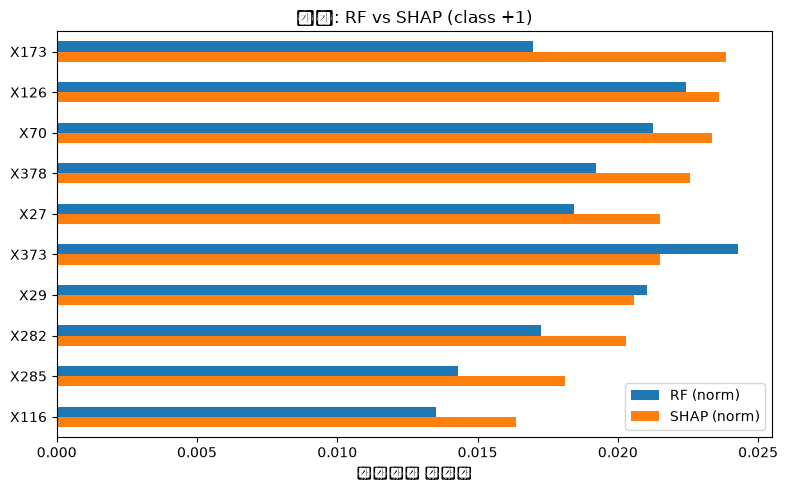

      RF (norm)  SHAP (norm)
X173     0.0170       0.0239
X126     0.0224       0.0236
X70      0.0213       0.0234
X378     0.0192       0.0226
X27      0.0184       0.0215
X373     0.0243       0.0215
X29      0.0210       0.0206
X282     0.0173       0.0203
X285     0.0143       0.0181
X116     0.0135       0.0164


,RF (norm),SHAP (norm)
X173,0.016975,0.023864
X126,0.022421,0.023591
X70,0.021257,0.023363
X378,0.019221,0.022574
X27,0.018447,0.021496
X373,0.024285,0.021486
X29,0.021031,0.020566
X282,0.017265,0.020304
X285,0.014313,0.018132
X116,0.013535,0.016374


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compare_importance(model, shap_values, X, title, top_n=10):
    # RF importance
    rf_imp = pd.Series(model.feature_importances_, index=X.columns)
    
    # SHAP importance (bar plot과 동일: mean |SHAP|)
    if shap_values.ndim == 3:  # 분류: 클래스 1 기준
        shap_imp = pd.Series(np.abs(shap_values[:, :, 1]).mean(axis=0), index=X.columns)
    else:
        shap_imp = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns)
    
    # 정규화 (0~1)해서 나란히 비교
    compare = pd.DataFrame({
        'RF (norm)': rf_imp / rf_imp.sum(),
        'SHAP (norm)': shap_imp / shap_imp.sum()
    }).sort_values('SHAP (norm)', ascending=False).head(top_n)
    
    compare.plot.barh(figsize=(8, 5))
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.xlabel('정규화된 중요도')
    plt.tight_layout()
    plt.show()
    
    print(compare.round(4))
    return compare

# 회귀
compare_importance(rf_reg, shap_values_reg, X_train_reg, '회귀: RF vs SHAP')

# 분류 (클래스 +1 기준)
compare_importance(rf_cls, shap_values_cls, X_train_cls, '분류: RF vs SHAP (class +1)')

[분류모델에서 RF 중요도와 SHAP value 순위가 다르게 나온 이유가 뭘까?]

[AI의 대답]<br>
좋은 관찰입니다. 차트를 보면 **순위가 꽤 다르게** 나옵니다. 대표적으로:

- **X373**: RF 1위인데 SHAP(class +1)에서는 6위
- **X173**: SHAP 1위인데 RF에서는 6~7위

이건 버그가 아니라, **두 방법이 “중요하다”는 것을 정의하는 방식이 다르기 때문**입니다.

---

## 1. 먼저 질문 자체가 다릅니다

| | RF `feature_importances_` | SHAP (class +1) |
|---|---|---|
| **질문** | “트리를 나눌 때 **전반적으로** 이 변수가 얼마나 유용했나?” | “이 변수가 **클래스 +1 예측**을 평균 대비 얼마나 밀어 올렸나?” |
| **범위** | 전체 모델, **클래스 구분 없음** | **클래스 +1 기준**으로 따로 계산 |
| **단위** | Gini 불순도 감소 (split 횟수·깊이 반영) | 예측 확률/log-odds 변화량 |

비유하면:

- **RF** → “수업 전체에서 **가장 자주 칠판에 쓴** 개념”
- **SHAP** → “**+1번 답을 맞히는 데** 실제로 기여한” 개념

자주 쓰인 개념과, 특정 답에 결정적이었던 개념이 항상 같지는 않습니다.

---

## 2. X373이 RF 1위인 이유 — “분할의 일꾼”

RF 중요도는 트리가 쪼갤 때마다 **Gini 불순도가 얼마나 줄었는지**를 누적합니다.

```
RF importance ↑  =  split에 자주 등장
                 +  그 split이 클래스를 잘 갈라줌
                 +  트리 여러 개에서 반복 사용
```

**X373**은 아마 이런 변수입니다:

- 두 클래스(-1, +1)를 **전반적으로** 잘 나누는 split에 자주 쓰임
- 474개 변수 중 RF가 “일단 이걸로 쪼개자”고 **가장 많이 선택**한 변수

그래서 RF 1위가 됩니다.

하지만 “전체적으로 유용” ≠ “클래스 +1에만 특별히 기여”입니다.

---

## 3. X173이 SHAP 1위인 이유 — “+1 예측의 핵심 기여”

SHAP은 각 샘플마다 이렇게 묻습니다:

> “이 샘플이 +1로 예측될 때, **X173 값 때문에** 평균 예측에서 얼마나 위로 밀렸는가?”

**X173**은 이런 패턴일 수 있습니다:

- RF split에는 **상대적으로 덜** 등장 (전체 순위 6~7위)
- 하지만 등장하거나 값이 특정 구간일 때, **+1 쪽 확률을 크게 올리는** 역할

즉:

```
RF  : “자주 쓰이는가?”        → X373 승
SHAP: “+1 예측을 얼마나 바꾸는가?” → X173 승
```

차트에서 X173은 주황(SHAP) 막대가 길고 파랑(RF) 막대가 짧은 전형적인 케이스입니다.

---

## 4. 왜 분류에서 차이가 회귀보다 더 눈에 띄나?

### ① RF는 클래스를 구분하지 않음

```python
rf_cls.feature_importances_   # 전체 모델 1개 순위
shap_values_cls[:, :, 1]      # 클래스 +1 전용 기여도
```

RF는 -1과 +1을 **한꺼번에** 잘 나누는 변수를 높게 줍니다.  
SHAP은 “**+1로 가는 방향**”만 봅니다.

X373이 두 클래스 분리에는 좋지만, +1 쪽으로 밀어주는 기여는 X173보다 작을 수 있습니다.

### ② 변수가 474개 — 상관·중복이 많음

분류 데이터는 `X1`~`X474`로 변수가 매우 많습니다.

- **RF**: 비슷한 변수가 있으면 split 기회를 **나눠 가짐**
- **SHAP**: Shapley 값으로 기여를 **공정 분배** (같은 정보끼리는 나눠 가짐)

그래서 RF 1위(X373)와 SHAP 1위(X173)가 갈라질 수 있습니다.

### ③ “자주 쓰임” vs “예측을 크게 바꿈”

| 상황 | RF | SHAP |
|------|-----|------|
| 트리 깊은 곳에서 자주 split | 높음 | 중간일 수 있음 |
| 특정 샘플에서 확률을 크게 바꿈 | 낮을 수 있음 | 높음 |
| 다른 변수와 정보가 겹침 | 한쪽에 쏠림 | 분산됨 |

---

## 5. 차트를 위에서부터 읽어보기

| 변수 | SHAP 순위 | RF 순위 | 해석 |
|------|-----------|---------|------|
| **X173** | 1위 | 6~7위 | +1 예측에 강한 영향, split에는 덜 쓰임 |
| **X126, X70** | 2~3위 | 2~3위 | 두 방법이 비슷하게 중요 → **핵심 변수** |
| **X378, X27** | 4~5위 | 낮음 | +1에 특화된 기여 |
| **X373** | 6위 | **1위** | 전체 분할의 일꾼, +1 전용 기여는 상대적으로 작음 |
| **X29** | 7위 | SHAP보다 RF가 더 큼 | split 기여가 SHAP 기여보다 큰 예외 케이스 |

**X126, X70**처럼 두 막대가 비슷한 변수는 “RF도 자주 쓰고, +1 예측에도 실질적으로 기여한다”고 보면 됩니다.

---

## 6. 선생님식 한 줄 정리

> **RF 중요도**는 “모델이 **트리를 나눌 때 가장 유용했던** 변수”이고,  
> **SHAP(class +1)** 은 “**+1로 예측할 때 실제로 예측을 바꾼** 변수”입니다.

그래서:

- **X373** → RF 1위: “분류 전체에서 가장 잘 쓰인 split 변수”
- **X173** → SHAP 1위: “+1 예측에 가장 크게 기여한 변수”

둘 다 틀린 게 아니라, **보는 관점이 다른 것**입니다.

---

## 7. 실무에서 어떻게 쓰면 좋을까?

| 목적 | 추천 |
|------|------|
| 모델이 어떤 변수로 전반적으로 나누는지 | RF `feature_importances_` |
| **클래스 +1**에 무엇이 기여하는지 | SHAP bar (class +1) |
| 변수가 +1 확률을 올리는지/내리는지 | SHAP dot summary plot |
| 두 방법 모두 상위인 변수 (X126, X70) | **가장 신뢰할 핵심 변수** |

분류에서는 **RF 순위와 SHAP(class +1) 순위를 나란히 보는 것**이 오히려 좋습니다.  
겹치는 변수는 “전반적으로도, +1 예측에도 중요”하고,  
어긋나는 변수(X373 vs X173)는 “역할이 다르다”는 신호입니다.

궁금하면 **X173 dependence plot**을 그려서 “값이 어떻게 변할 때 +1 쪽으로 밀리는지” 같이 보면 해석이 더 분명해집니다.

반도체공정 data로 추정모델을 만들고 결과를 해석한다고 했을때,
RF 중요도는 결과값이 정상 vs 불량일때 어떤 변수가 그 둘을 가르는데에 결정적이었는지 분석하기에 좋아보인다. 즉, 불량 개선이 필요할 때 중요 인자를 파악하기에 좋겠다. (개선 방향은 알수 없다는 한계. dependence plot까지 봐야 알 수 있다.)
SHAP는 결과값을 많이 올리거나 낮춘 변수가 어떤 것인지 파악하기에 좋아보인다. 즉, 공정 profile을 특정 target에 맞추고 싶을때 공정 parameter별 영향력을 확인하고 싶을때 좋겠다.